# 부스팅(Boosting)
- 기본적으로는 랜덤 포래스트와 유사한다.
- 다른 점은 각 트리들이 던지는 답의 오차들을 보정할 수 있도록 오차 함수가 존재한다.
- 이를 통해 성능을 끌어 올린다.
- 너어어어어어어어어어어어어어어무 오래걸려요.ㅠㅠ(차라리 딥러닝을 쓰고 말지.ㅠㅠㅠㅠ)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm


In [ ]:
# 기본

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 혼동행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install shap

### 분류

In [ ]:
# 데이터 준비
train_df = pd.read_parquet('/content/drive/MyDrive/공유문서함/all_df07VIF끝.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/test데이터/test07.parquet')
target_df = pd.read_csv('/content/drive/MyDrive/Segment.csv')

display(train_df.columns)
display(test_df.columns)

Index(['이용카드수_신용체크', '_2순위카드이용금액', '정상입금원금_B0M', '이용금액_오프라인_R3M',
       '이용건수_신용_R12M', '쇼핑_도소매_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
       '쇼핑_슈퍼마켓_이용금액', '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M',
       '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드', '청구금액_R6M', '월중평잔_일시불_B0M',
       '이용금액대', '이용가능여부_해외겸용_본인', '상향가능한도금액', '상향가능CA한도금액', '할인건수_R3M',
       '인입횟수_ARS_R6M', '수신거부여부_TM', '수신거부여부_메일', 'Cluster'],
      dtype='object')

Index(['기준년월', 'ID', '이용가능여부_해외겸용_본인', '보유여부_해외겸용_본인', '수신거부여부_TM',
       '수신거부여부_메일', '수신거부여부_DM', '이용금액_R3M_신용체크', '이용금액_R3M_신용', '_1순위카드이용금액',
       '이용카드수_신용체크', '_2순위카드이용금액', '_1순위카드이용건수', '_2순위카드이용건수', '이용카드수_신용',
       '상향가능한도금액', '상향가능CA한도금액', '정상청구원금_B5M', '정상청구원금_B0M', '정상청구원금_B2M',
       '이용금액_일시불_R12M', '이용금액_일시불_B0M', '이용금액_오프라인_B0M', '이용금액_일시불_R6M',
       '이용금액_일시불_R3M', '정상입금원금_B5M', '정상입금원금_B0M', '이용금액_오프라인_R3M',
       '이용금액_오프라인_R6M', '정상입금원금_B2M', '_3순위업종_이용금액', '_2순위업종_이용금액',
       '이용건수_신용_R12M', '_2순위쇼핑업종_이용금액', '최대이용금액_일시불_R12M', '이용건수_신판_R12M',
       '이용건수_일시불_R12M', '_1순위업종_이용금액', '_3순위쇼핑업종_이용금액', '이용가맹점수',
       '이용건수_오프라인_B0M', '이용건수_오프라인_R6M', '이용건수_오프라인_R3M', '쇼핑_도소매_이용금액',
       '이용건수_신용_R6M', '이용건수_신용_B0M', '이용건수_신용_R3M', '이용건수_신판_R6M',
       '이용건수_신판_B0M', '이용건수_신판_R3M', '이용건수_일시불_R6M', '이용건수_일시불_B0M',
       '이용건수_일시불_R3M', '_1순위교통업종_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
       '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '이용금액_온라인_B0M', '연체입금원금_B5M', '연체입금원금_B2

In [ ]:
train_df = train_df[['이용카드수_신용체크', '_2순위카드이용금액', '정상입금원금_B0M', '이용금액_오프라인_R3M',
       '이용건수_신용_R12M', '쇼핑_도소매_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
       '쇼핑_슈퍼마켓_이용금액', '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M',
       '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드', '청구금액_R6M', '월중평잔_일시불_B0M',
       '이용금액대', '이용가능여부_해외겸용_본인', '상향가능한도금액', '상향가능CA한도금액', '할인건수_R3M',
       '인입횟수_ARS_R6M', '수신거부여부_TM', '수신거부여부_메일']]

In [ ]:
test_df = test_df[['이용카드수_신용체크', '_2순위카드이용금액', '정상입금원금_B0M', '이용금액_오프라인_R3M',
       '이용건수_신용_R12M', '쇼핑_도소매_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
       '쇼핑_슈퍼마켓_이용금액', '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M',
       '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드', '청구금액_R6M', '월중평잔_일시불_B0M',
       '이용금액대', '이용가능여부_해외겸용_본인', '상향가능한도금액', '상향가능CA한도금액', '할인건수_R3M',
       '인입횟수_ARS_R6M', '수신거부여부_TM', '수신거부여부_메일']]

In [ ]:
target_df['Segment'].value_counts()

,count
Segment,
E,1922052
D,349242
C,127590
A,972
B,144


In [ ]:
target_df = target_df.query('기준년월 ==201807')

In [ ]:
encoder1 = LabelEncoder()
Seg = encoder1.fit_transform(target_df['Segment'])


In [ ]:
Seg

array([3, 4, 2, ..., 2, 4, 4])

In [ ]:
# 입력과 결과로 나눈다.
X = train_df
y = Seg

In [ ]:
from sklearn.model_selection import train_test_split

# 전체 데이터: X, 정답 레이블: y
X_train, X_val, y_train, y_val = train_test_split(
    X, y,              # 데이터와 정답
    test_size=0.2,     # 검증용 데이터 비율 (20%)
    stratify=y,        # 클래스 비율 유지
    random_state=42    # 결과 재현을 위한 시드
)

In [ ]:
X_test = test_df

In [ ]:
train_X_df = pd.DataFrame(X_train)
train_y_df = pd.DataFrame(y_train)

### 기본 모델 사용하기

In [ ]:
print(pd.Series(y_train).unique())

[3 4 2 0 1]


In [ ]:
print(pd.Series(y_train).value_counts())

4    320342
3     58207
2     21265
0       162
1        24
Name: count, dtype: int64


In [ ]:
model5 = LGBMClassifier(device='gpu', verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
r1 = cross_val_score(model5, train_X, y_train, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.85976


In [ ]:
model6 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

r2 = cross_val_score(model6, train_X, y_train, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r2.mean()}')

평균 f1 Score : 0.86747


In [ ]:
10/0

ZeroDivisionError: division by zero

| 클래스 | 샘플 수    | 기본 가중치(역수) | 완화된 가중치(로그) | 추천 가중치 (예시) |
|--------|------------|-------------------|---------------------|--------------------|
| 4      | 1,922,052  | 0.25              | 0.22                | 1                  |
| 3      | 349,242    | 1.37              | 0.95                | 1.5                |
| 2      | 127,590    | 3.76              | 1.5                 | 4                  |
| 0      | 972        | 493.9             | 6.2                 | 50                 |
| 1      | 144        | 3330.5            | 7.8                 | 50                 |


In [ ]:
### 가중치 줘보기
class_weights = {0: 50., 1: 50, 2: 4, 3: 1.5, 4: 1}

In [ ]:
model3 = LGBMClassifier(device='gpu', class_weight=class_weights, verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
r3 = cross_val_score(model3, train_X, y_train, scoring='f1_weighted', cv=kfold)
print(f'평균 f1 Score : {r3.mean()}')

KeyboardInterrupt: 

In [ ]:
model4 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

# 클래스별 가중치 예시

f1_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_X, y_train)):
    X_tr, X_val = train_X.iloc[train_idx], train_X.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]   # .iloc → []

    sample_weights = np.array([class_weights[label] for label in y_tr])

    model4.fit(X_tr, y_tr, sample_weight=sample_weights)
    preds = model4.predict(X_val)

    f1 = f1_score(y_val, preds, average='weighted')
    f1_scores.append(f1)
    print(f'Fold {fold+1} F1 Score: {f1:.4f}')


Fold 1 F1 Score: 0.8543
Fold 2 F1 Score: 0.8575
Fold 3 F1 Score: 0.8524
Fold 4 F1 Score: 0.8531
Fold 5 F1 Score: 0.8553
Fold 6 F1 Score: 0.8528
Fold 7 F1 Score: 0.8564
Fold 8 F1 Score: 0.8569
Fold 9 F1 Score: 0.8554
Fold 10 F1 Score: 0.8553


### 모델 하이퍼 파라미터 튜닝

In [ ]:
10/0

In [ ]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [250,300,350],
    'learning_rate' : [0.01, 0.05]
}
# 사용할 모델 객체를 생성한다.
model1 = LGBMClassifier(device='gpu', verbose=-1)
# 최적의 하이퍼 파라미터를 찾는다.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
grid_clf1 = GridSearchCV(model1, param_grid=params, scoring='f1_micro', cv=kfold)
grid_clf1.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf1.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf1.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.05, 'n_estimators': 300}
최적의 모델 평균 성능 : 0.864335


In [ ]:
# 튜닝할 하이퍼 파라미터 후보 값
# booster : 내부에서 사용할 알고리즘. gbtree - 결정트리, gblinear - 선형모델
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도

params = {
    'booster' : ['gbtree'],
    'n_estimators' : [400, 450, 500],
    'learning_rate' : [0.05, 0.1, 0.3]
}

model2 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='f1_micro', cv=kfold, n_jobs=-1)
grid_clf2.fit(train_X, train_y)

print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf2.best_score_:.4f}')

최적의 하이퍼 파라미터 : {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 450}
최적의 모델 평균 성능 : 0.8683


### 예측을 수행한다

In [ ]:
이용금액대encoder = LabelEncoder()
test_df['이용금액대'] = 이용금액대encoder.fit_transform(test_df['이용금액대'])
할인건수encoder = LabelEncoder()
test_df['할인건수_R3M'] = 할인건수encoder.fit_transform(test_df['할인건수_R3M'])
인입횟수encoder = LabelEncoder()
test_df['인입횟수_ARS_R6M'] = 인입횟수encoder.fit_transform(test_df['인입횟수_ARS_R6M'])

In [ ]:
# 예측할 데이터를 읽어온다.
df1 = test_df.copy()
df2 = df1.copy()
df3 = df2.copy()
df4 = df3.copy()
df5 = df4.copy()
df6 = df5.copy()
df1

,이용카드수_신용체크,_2순위카드이용금액,정상입금원금_B0M,이용금액_오프라인_R3M,이용건수_신용_R12M,쇼핑_도소매_이용금액,연체입금원금_B0M,쇼핑_마트_이용금액,쇼핑_슈퍼마켓_이용금액,연체입금원금_B5M,...,청구금액_R6M,월중평잔_일시불_B0M,이용금액대,이용가능여부_해외겸용_본인,상향가능한도금액,상향가능CA한도금액,할인건수_R3M,인입횟수_ARS_R6M,수신거부여부_TM,수신거부여부_메일
0,2,6021,3680,19611,150,0,2814,854,350,2414,...,22151,6412,1,1,7,2,1,1,1,1
1,2,0,8726,5489,28,1033,918,1154,0,2959,...,32878,1010,1,1,0,0,1,1,0,0
2,2,10704,11297,41402,650,1679,222,1064,1094,0,...,71867,4407,0,0,0,0,1,1,0,0
3,1,0,1375,5343,361,824,0,804,634,0,...,4986,1107,3,1,3,1,1,1,0,0
4,3,6387,3951,7567,227,890,0,774,323,0,...,10758,1072,2,1,2,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,0,0,0,0,0,0,0,0,517,...,353,0,5,0,5,1,1,1,0,0
99996,1,0,302,671,-1,0,689,0,0,0,...,3154,366,4,0,7,2,1,1,0,0
99997,0,0,0,0,0,0,0,0,0,0,...,0,0,5,0,4,1,1,1,0,0
99998,4,32807,6215,62955,906,2218,12448,1911,1120,13863,...,96169,20859,0,1,8,2,1,1,1,1


In [ ]:
y_pred1 = grid_clf1.predict(df1)
y_pred2 = grid_clf2.predict(df2)

In [ ]:
model4

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
model4.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
model5

LGBMClassifier(device='gpu', verbose=-1)

In [ ]:
model5.fit(train_X, train_y)

LGBMClassifier(device='gpu', verbose=-1)

In [ ]:
model6

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, predictor='gpu_predictor', ...)

In [ ]:
model6.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
y_pred4 = model4.predict(df4)

In [ ]:
model5.fit(train_X, train_y)
y_pred5= model5.predict(df5)

In [ ]:
model6.fit(train_X, train_y)
y_pred6= model6.predict(df6)

In [ ]:
y_true = target_df

## 혼동행렬

In [ ]:
예측용결과40만개 = y_true['Segment']
예측용결과40만개.value_counts()

,count
Segment,
E,320342
D,58207
C,21265
A,162
B,24


In [ ]:
예측용결과40만개

,Segment
0,D
1,E
2,C
3,D
4,E
...,...
399995,E
399996,D
399997,C
399998,E


In [ ]:
# 혼동행렬을 위한 새로운 데이터프레임 생성
예측용데이터40만개 = train_X
예측용데이터40만개['Segment'] = 예측용결과40만개
# 인코딩
예측용인코더 = LabelEncoder()
y_true = 예측용인코더.fit_transform(예측용데이터40만개['Segment'])

In [ ]:
# 예측용 데이터와 예측용 결과데이터로 나눠준다
혼동X = 예측용데이터40만개.drop('Segment', axis=1)

In [ ]:
y_pred7 = grid_clf1.predict(혼동X)
y_pred8 = grid_clf2.predict(혼동X)
y_pred9 = model4.predict(혼동X)
y_pred10 = model5.predict(혼동X)
y_pred11 = model6.predict(혼동X)

In [ ]:
result_data1 = encoder1.inverse_transform(y_pred1)
result_data2 = encoder1.inverse_transform(y_pred2)
result_data4 = encoder1.inverse_transform(y_pred4)
result_data5 = encoder1.inverse_transform(y_pred5)
result_data6 = encoder1.inverse_transform(y_pred6)

In [ ]:
result_data7 = 예측용인코더.inverse_transform(y_pred7)
result_data8 = 예측용인코더.inverse_transform(y_pred8)
result_data9 = 예측용인코더.inverse_transform(y_pred9)
result_data10 = 예측용인코더.inverse_transform(y_pred10)
result_data11 = 예측용인코더.inverse_transform(y_pred11)

In [ ]:
result_data7

array(['D', 'E', 'E', ..., 'E', 'E', 'E'], dtype=object)

In [ ]:
values, counts = np.unique(result_data7, return_counts=True)

# 보기 좋게 정리
for val, count in zip(values, counts):
    print(f"{val}: {count}")

A: 212
B: 94
C: 15572
D: 47090
E: 337032


In [ ]:
values, counts = np.unique(result_data6, return_counts=True)

# 보기 좋게 정리
for val, count in zip(values, counts):
    print(f"{val}: {count}")

A: 5
B: 1
C: 3792
D: 10485
E: 85717


In [ ]:
result_data7

array(['D', 'E', 'E', ..., 'E', 'E', 'E'], dtype=object)

In [ ]:
y_true = 예측용인코더.inverse_transform(y_true)

In [ ]:
y_true

array(['D', 'E', 'C', ..., 'C', 'E', 'E'], dtype=object)

In [ ]:
result_data5
result_data6

array(['E', 'E', 'D', ..., 'E', 'C', 'E'], dtype=object)

In [ ]:
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


<Figure size 600x600 with 0 Axes>

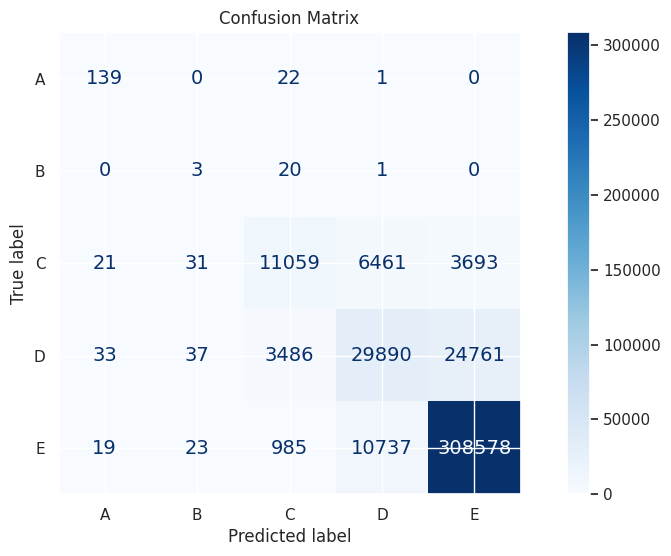

In [ ]:
# 예측 결과 (y_pred), 실제 정답 (y_true)
cm = confusion_matrix(y_true, result_data7, labels=['A', 'B', 'C', 'D', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D', 'E'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


<Figure size 600x600 with 0 Axes>

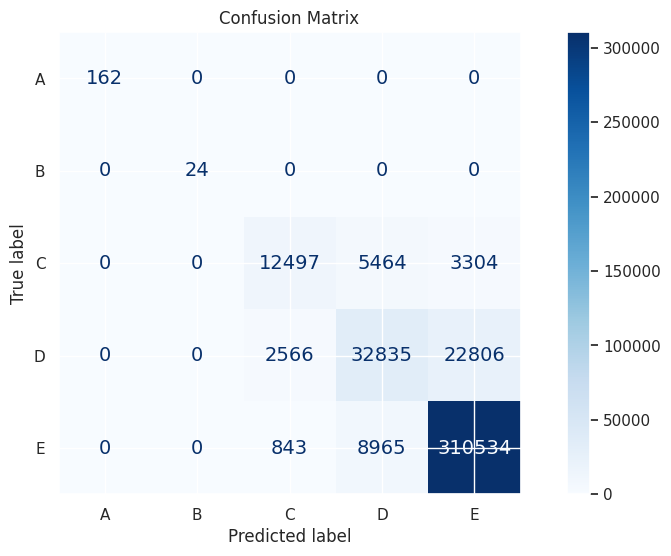

In [ ]:
# 예측 결과 (y_pred), 실제 정답 (y_true)
cm = confusion_matrix(y_true, result_data8, labels=['A', 'B', 'C', 'D', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D', 'E'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

<Figure size 600x600 with 0 Axes>

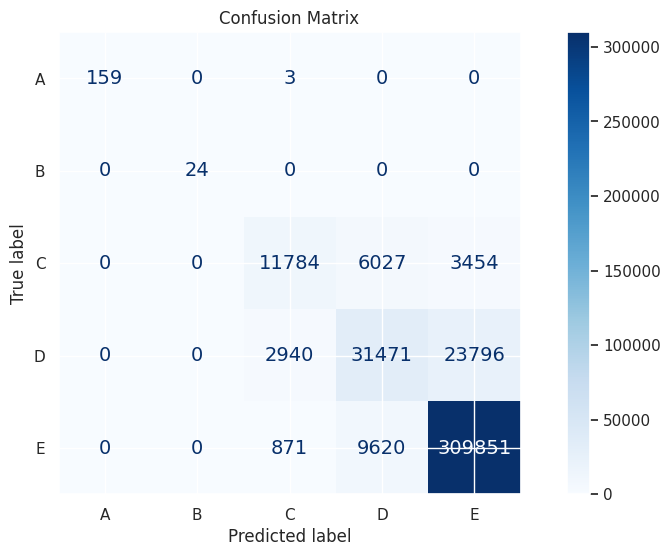

In [ ]:
# 예측 결과 (y_pred), 실제 정답 (y_true)
cm = confusion_matrix(y_true, result_data9, labels=['A', 'B', 'C', 'D', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D', 'E'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

<Figure size 600x600 with 0 Axes>

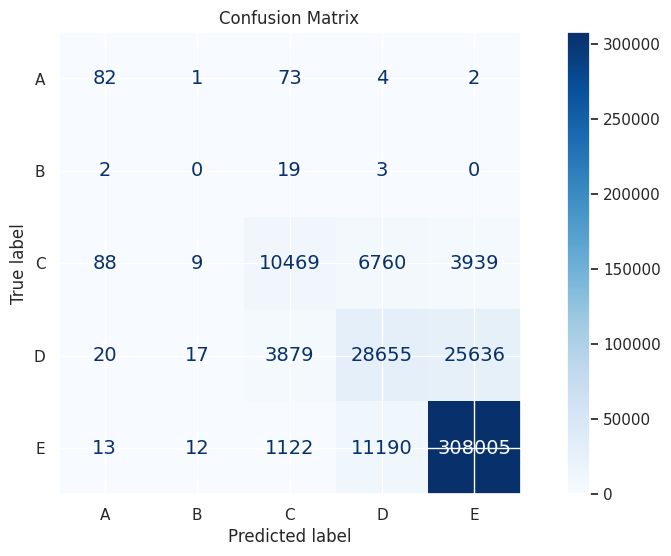

In [ ]:
# 예측 결과 (y_pred), 실제 정답 (y_true)
cm = confusion_matrix(y_true, result_data10, labels=['A', 'B', 'C', 'D', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D', 'E'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

<Figure size 600x600 with 0 Axes>

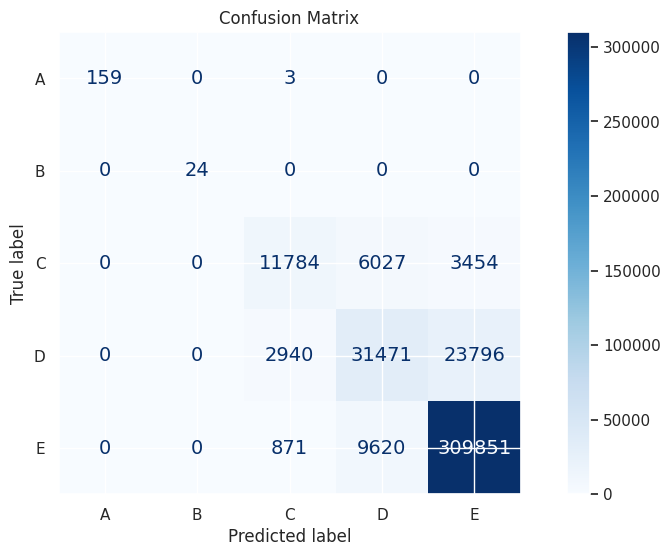

In [ ]:
# 예측 결과 (y_pred), 실제 정답 (y_true)
cm = confusion_matrix(y_true, result_data11, labels=['A', 'B', 'C', 'D', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D', 'E'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, result_data11))

              precision    recall  f1-score   support

           A       1.00      0.98      0.99       162
           B       1.00      1.00      1.00        24
           C       0.76      0.55      0.64     21265
           D       0.67      0.54      0.60     58207
           E       0.92      0.97      0.94    320342

    accuracy                           0.88    400000
   macro avg       0.87      0.81      0.83    400000
weighted avg       0.87      0.88      0.88    400000



In [ ]:
print(classification_report(y_true, result_data8))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       162
           B       1.00      1.00      1.00        24
           C       0.79      0.59      0.67     21265
           D       0.69      0.56      0.62     58207
           E       0.92      0.97      0.95    320342

    accuracy                           0.89    400000
   macro avg       0.88      0.82      0.85    400000
weighted avg       0.88      0.89      0.88    400000



In [ ]:
print(classification_report(y_true, result_data9))

              precision    recall  f1-score   support

           A       1.00      0.98      0.99       162
           B       1.00      1.00      1.00        24
           C       0.76      0.55      0.64     21265
           D       0.67      0.54      0.60     58207
           E       0.92      0.97      0.94    320342

    accuracy                           0.88    400000
   macro avg       0.87      0.81      0.83    400000
weighted avg       0.87      0.88      0.88    400000



In [ ]:
# 예측 결과데이터를 만들기
submission_df = pd.read_parquet('/content/drive/MyDrive/test데이터/신용카드데이터_test.parquet')
submission_df1 = submission_df[-100000:]
submission_df2 = submission_df[-100000:]
submission_df3 = submission_df[-100000:]

In [ ]:
submission_df2 = submission_df2[:100000]

In [ ]:
result_data2

array(['E', 'E', 'D', ..., 'E', 'C', 'E'], dtype=object)

In [ ]:
result_data4
result_data6

array(['E', 'E', 'D', ..., 'E', 'C', 'E'], dtype=object)

In [ ]:
submission_df2

,기준년월,ID,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,...,청구금액_R3M,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M
0,201807,TEST_00000,1,1,1,1,1,21458,21458,13852,...,11441,4931,1회 이상,6412,5187,3841,4802,2277,0,1회 이상
1,201807,TEST_00001,1,1,0,0,0,18681,10759,11065,...,20522,10152,1회 이상,1010,865,844,1201,1467,544,1회 이상
2,201807,TEST_00002,0,0,0,0,0,40758,40758,27071,...,50508,13223,1회 이상,4407,5591,5606,3046,2496,3096,1회 이상
3,201807,TEST_00003,1,1,0,0,0,5255,5255,4827,...,4604,2112,1회 이상,1107,1545,1510,768,675,1035,1회 이상
4,201807,TEST_00004,1,1,1,1,1,16148,14290,8011,...,6788,4406,1회 이상,1072,1462,1373,637,1395,620,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,201807,TEST_99995,0,1,0,0,0,0,0,0,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
99996,201807,TEST_99996,0,0,0,0,0,851,851,941,...,1274,363,1회 이상,366,349,312,282,322,179,1회 이상
99997,201807,TEST_99997,0,0,0,0,0,0,0,0,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
99998,201807,TEST_99998,1,1,1,1,1,145907,115541,68462,...,85645,22932,1회 이상,20859,20928,17798,18924,23108,16854,1회 이상


In [ ]:

submission_df1 = submission_df1[['ID','기준년월']]
submission_df2 = submission_df2[['ID','기준년월']]
submission_df3 = submission_df3[['ID','기준년월']]

submission_df1['Segment'] = result_data2
submission_df2['Segment'] = result_data4
submission_df3['Segment'] = result_data6

In [ ]:
submission_df2['Segment'].value_counts()


,count
Segment,
E,85717
D,10485
C,3792
A,5
B,1


In [ ]:
submission_df1['Segment'].value_counts()

,count
Segment,
E,85526
D,10645
C,3823
A,5
B,1


In [ ]:
submission_df3['Segment'].value_counts()

,count
Segment,
E,85717
D,10485
C,3792
A,5
B,1


In [ ]:
submission_df1.drop('기준년월', axis=1, inplace=True)
submission_df2.drop('기준년월', axis=1, inplace=True)
submission_df3.drop('기준년월', axis=1, inplace=True)

In [ ]:
submission_df1.to_csv('/content/drive/MyDrive/공유문서함/XGBhyper.csv', index=False)
submission_df2.to_csv('/content/drive/MyDrive/공유문서함/XGB가중치.csv', index=False)
submission_df3.to_csv('/content/drive/MyDrive/공유문서함/XGBbasic.csv', index=False)

In [ ]:
10/0

In [ ]:
import joblib
# 전처리기와 모델을 하나의 딕셔너리에 묶기
bundle = {
    'encoder': encoder1,
    'models': {
        'xgb_basic': model6,
        'lgbm_basic': model5,
        'lgbm_tuned': grid_clf1.best_estimator_,
        'xgb_tuned': grid_clf2.best_estimator_,
        'xgb_weight': model4
    },
    'params': {
        'xgb_basic': model6.get_params(),
        'lgbm_tuned': grid_clf1.best_params_,
        'xgb_tuned': grid_clf2.best_params_
    },
    'feature_names': train_X.columns.tolist()
}

# 저장
joblib.dump(bundle, '/content/drive/MyDrive/model/bundle1.pkl')

['/content/drive/MyDrive/model/bundle1.pkl']

In [ ]:
import pickle
# 전처리기와 모델을 하나의 딕셔너리에 묶기
bundle = {
    'encoder': encoder1,
    'models': {
        'xgb_basic': model6,
        'lgbm_basic': model5,
        'lgbm_tuned': grid_clf1.best_estimator_,
        'xgb_tuned': grid_clf2.best_estimator_,
        'xgb_weight': model4
    },
    'params': {
        'xgb_basic': model6.get_params(),
        'lgbm_tuned': grid_clf1.best_params_,
        'xgb_tuned': grid_clf2.best_params_
    },
    'feature_names': train_X.columns.tolist()
}

# 저장
with open('/content/drive/MyDrive/model/bundle1_1.pkl', 'wb') as f:
    pickle.dump(bundle, f)

In [ ]:
test_df = pd.read_parquet('/content/drive/MyDrive/test데이터/test12.parquet')

In [ ]:
test_df = test_df[['이용카드수_신용체크', '_2순위카드이용금액', '정상입금원금_B0M', '이용금액_오프라인_R3M',
       '이용건수_신용_R12M', '쇼핑_도소매_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
       '쇼핑_슈퍼마켓_이용금액', '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M',
       '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드', '청구금액_R6M', '월중평잔_일시불_B0M',
       '이용금액대', '이용가능여부_해외겸용_본인', '상향가능한도금액', '상향가능CA한도금액', '할인건수_R3M',
       '인입횟수_ARS_R6M', '수신거부여부_TM', '수신거부여부_메일']]

In [ ]:
test_X = test_df

In [ ]:
이용금액대encoder = LabelEncoder()
test_df['이용금액대'] = 이용금액대encoder.fit_transform(test_df['이용금액대'])
할인건수encoder = LabelEncoder()
test_df['할인건수_R3M'] = 할인건수encoder.fit_transform(test_df['할인건수_R3M'])
인입횟수encoder = LabelEncoder()
test_df['인입횟수_ARS_R6M'] = 인입횟수encoder.fit_transform(test_df['인입횟수_ARS_R6M'])

In [ ]:
# 예측할 데이터를 읽어온다.
df1 = test_df.copy()
df2 = df1.copy()
df3 = df2.copy()
df4 = df3.copy()
df5 = df4.copy()
df6 = df5.copy()
df1

,이용카드수_신용체크,_2순위카드이용금액,정상입금원금_B0M,이용금액_오프라인_R3M,이용건수_신용_R12M,쇼핑_도소매_이용금액,연체입금원금_B0M,쇼핑_마트_이용금액,쇼핑_슈퍼마켓_이용금액,연체입금원금_B5M,...,청구금액_R6M,월중평잔_일시불_B0M,이용금액대,이용가능여부_해외겸용_본인,상향가능한도금액,상향가능CA한도금액,할인건수_R3M,인입횟수_ARS_R6M,수신거부여부_TM,수신거부여부_메일
0,2,4637,4359,29525,110,0,727,956,419,2814,...,26492,5692,1,1,6,2,1,1,1,1
1,2,0,12191,11909,54,0,0,1254,0,918,...,89983,471,1,1,0,0,1,1,0,0
2,2,10227,10049,31576,525,1653,0,1297,1497,222,...,74074,4226,1,0,0,0,1,1,0,0
3,1,0,1234,2902,317,636,0,719,370,0,...,12439,1267,3,1,3,1,1,1,0,0
4,3,7696,993,2932,182,810,0,737,308,0,...,12830,616,3,1,3,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,0,0,0,0,0,0,0,0,0,...,0,0,5,0,0,0,1,1,0,0
99996,1,0,205,1178,7,0,0,0,0,689,...,2237,260,4,0,8,2,1,1,0,0
99997,0,0,0,0,0,0,0,0,0,0,...,0,0,5,0,5,1,1,1,0,0
99998,6,31916,0,44309,933,2208,16746,1632,848,12448,...,108420,16911,0,1,9,2,1,1,1,1


In [ ]:
y_pred1 = grid_clf1.predict(df1)
y_pred2 = grid_clf2.predict(df2)

In [ ]:
result_data1 = encoder1.inverse_transform(y_pred1)
result_data2 = encoder1.inverse_transform(y_pred2)

In [ ]:
# 예측 결과데이터를 만들기
submission_df = pd.read_parquet('/content/drive/MyDrive/test데이터/신용카드데이터_test.parquet')
submission_df1 = submission_df[-100000:]
submission_df2 = submission_df[-100000:]
submission_df3 = submission_df[-100000:]

In [ ]:

submission_df1 = submission_df1[['ID','기준년월']]

submission_df1['Segment'] = result_data2


In [ ]:
submission_df1['Segment'].value_counts()

,count
Segment,
E,86347
D,10155
C,3497
A,1


In [ ]:
submission_df1.drop('기준년월', axis=1, inplace=True)

In [ ]:
submission_df1

,ID,Segment
500000,TEST_00000,E
500001,TEST_00001,E
500002,TEST_00002,D
500003,TEST_00003,E
500004,TEST_00004,E
...,...,...
599995,TEST_99995,E
599996,TEST_99996,E
599997,TEST_99997,E
599998,TEST_99998,C


In [ ]:
submission_df1.to_csv('/content/drive/MyDrive/공유문서함/XGBhyper12.csv', index=False)